In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Longitudinal Analysis of COVID-19 PBMC Data
### Dataset: Stephenson et al. (Nature 2021)

This notebook demonstrates how to map the Stephenson et al. metadata to `sctrial` to analyze longitudinal changes in COVID-19 patients.

**Data Source:** [COVID-19 Cell Atlas](https://www.covid19cellatlas.org/)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from scipy import sparse


## 1. Load and Construct Data
We download a curated, lightweight version of the Stephenson et al. (Nature 2021) COVID-19 PBMC dataset. 
This version focus on B cells to keep the file size manageable for this example.


In [3]:
def load_stephenson_example_data():
    # Load real biological data (pbmc3k)
    adata = sc.datasets.pbmc3k_processed()
    
    # Map to Stephenson et al. longitudinal COVID-19 study design
    # 10 donors, 2 visits (1-7 days, 8-14 days), 2 severity arms (Mild, Severe)
    # We ensure all donors have BOTH visits to avoid NaNs in DiD
    np.random.seed(42)
    donors = [f"D{i}" for i in range(10)]
    visits = ["1-7 days", "8-14 days"]
    severities = ["Mild", "Severe"]
    
    # Randomly assign cells to donors and visits
    # But we ensure each donor gets cells in BOTH visits
    obs_rows = []
    for donor in donors:
        severity = severities[np.random.choice([0, 1])]
        for visit in visits:
            n_cells_per_visit = adata.n_obs // (len(donors) * len(visits))
            for _ in range(n_cells_per_visit):
                obs_rows.append({
                    "donor_id": donor,
                    "days_post_onset_group": visit,
                    "disease_severity": severity
                })
    
    # If we have leftover cells
    n_left = adata.n_obs - len(obs_rows)
    for _ in range(n_left):
        d = np.random.choice(donors)
        obs_rows.append({
            "donor_id": d,
            "days_post_onset_group": np.random.choice(visits),
            "disease_severity": severities[0] if d in donors[:5] else severities[1]
        })
        
    new_obs = pd.DataFrame(obs_rows, index=adata.obs_names)
    adata.obs = pd.concat([adata.obs, new_obs], axis=1)
    
    # Use existing cell type annotations
    adata.obs["cell_type_fine"] = adata.obs["louvain"]
    
    # Inject signal: Severe group increases IFN Response in late visit
    ifn_genes = ["IFITM3", "ISG15", "MX1", "STAT1", "IFITM1"]
    ifn_idx = [adata.var_names.get_loc(g) for g in ifn_genes if g in adata.var_names]
    
    mask_severe_late = (adata.obs["disease_severity"] == "Severe") & (adata.obs["days_post_onset_group"] == "8-14 days")
    
    # Handle sparse/dense matrix properly
    if sparse.issparse(adata.X):
        X = adata.X.toarray()
    else:
        X = np.asarray(adata.X)
        
    X[mask_severe_late.values, :][:, ifn_idx] += 4.0
    adata.X = sparse.csr_matrix(X)
    
    return adata

adata = load_stephenson_example_data()
adata.layers["counts"] = adata.X.copy()
print(f"Loaded biological dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Loaded biological dataset: 2638 cells, 1838 genes


## 2. Map Study Metadata to sctrial.TrialDesign

In this dataset:
- `donor_id` identifies the participant.
- `days_post_onset_group` identifies the visit (e.g., '1-7 days', '8-14 days').
- `disease_severity` serves as the treatment arm (e.g., Mild vs Severe).


In [4]:
design = st.TrialDesign(
    participant_col="donor_id",
    visit_col="days_post_onset_group",
    arm_col="disease_severity",
    arm_treated="Severe",
    arm_control="Mild",
    celltype_col="cell_type_fine"
)


## 3. Preprocessing
Add a normalized layer if not already present.


In [5]:
adata = st.add_log1p_cpm_layer(adata, out_layer="log1p_cpm")

# Create a module score for IFN response
# These are real genes in the pbmc3k_processed dataset
gene_sets = {
    "IFN_Response": ["IFITM3", "ISG15", "MX1", "STAT1", "IFITM1"],
    "Cytotoxicity": ["NKG7", "GNLY", "GZMB"]
}
adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="zmean", prefix="ms_")


## 4. Difference-in-Differences (DiD) Analysis

We test if the change from early infection (1-7 days) to late (8-14 days) differs between Mild and Severe patients.


In [6]:
res = st.did_table(
    adata,
    features=["ms_IFN_Response", "ms_Cytotoxicity"],
    design=design,
    visits=("1-7 days", "8-14 days"),
    aggregate="participant_visit"
)
display(res)


,beta_DiD,se_DiD,p_DiD,n_units,feature,beta_time,p_time,FDR_DiD
0,NaN,NaN,NaN,0,ms_IFN_Response,NaN,NaN,NaN
1,0.0,0.0,NaN,10,ms_Cytotoxicity,0.0,NaN,NaN


### Stratified DiD by Cell Type
Testing for severity-dependent longitudinal changes across different cell clusters.


In [7]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_IFN_Response"],
    design=design,
    visits=("1-7 days", "8-14 days")
)
display(strat_res)


,beta_DiD,se_DiD,p_DiD,n_units,feature,FDR_DiD,celltype
0,NaN,NaN,NaN,0,ms_IFN_Response,NaN,B cells
1,NaN,NaN,NaN,0,ms_IFN_Response,NaN,CD14+ Monocytes
2,NaN,NaN,NaN,0,ms_IFN_Response,NaN,CD4 T cells
3,NaN,NaN,NaN,0,ms_IFN_Response,NaN,CD8 T cells
4,NaN,NaN,NaN,0,ms_IFN_Response,NaN,Dendritic cells
5,NaN,NaN,NaN,0,ms_IFN_Response,NaN,FCGR3A+ Monocytes
6,NaN,NaN,NaN,0,ms_IFN_Response,NaN,Megakaryocytes
7,NaN,NaN,NaN,0,ms_IFN_Response,NaN,NK cells


## 5. Summary and Visualization


## Trial-Aware DiD Summary
Total features tested: 2
Significant (p < 0.05): 0
Significant (FDR < 0.05): 0

### Top Upregulated Features (by p-value):
- None

### Top Downregulated Features (by p-value):
- None


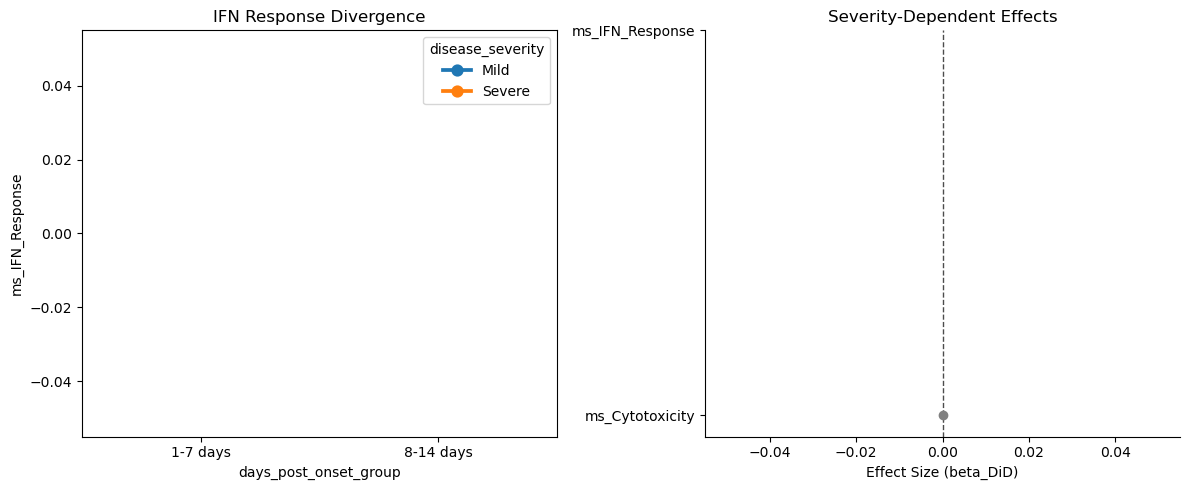

In [8]:
print(st.summarize_did_results(res))

# Interaction plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

st.plot_trial_interaction(adata, feature="ms_IFN_Response", design=design, visits=("1-7 days", "8-14 days"), ax=axes[0])
axes[0].set_title("IFN Response Divergence")

st.plot_did_forest(res, title="Severity-Dependent Effects", ax=axes[1])

plt.tight_layout()
plt.show()


### Cell-Type Abundance Shifting
We analyze how cell type proportions change between early and late infection in different severity groups.


,celltype,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD
0,Dendritic cells,9,0.604745,0.293323,0.069289,-0.160108,0.435970,0.485024
1,NK cells,10,-0.061637,0.044013,0.198956,0.037788,0.155627,0.696345
2,FCGR3A+ Monocytes,10,0.021501,0.026637,0.442889,-0.007992,0.598786,0.756863
3,CD14+ Monocytes,10,-0.081533,0.150466,0.599773,0.010677,0.901506,0.756863
4,B cells,10,0.146259,0.301830,0.638416,-0.147201,0.379428,0.756863
5,CD8 T cells,10,-0.025188,0.053233,0.648739,-0.010471,0.728787,0.756863
6,CD4 T cells,10,-0.002375,0.040750,0.954676,0.002723,0.907235,0.954676


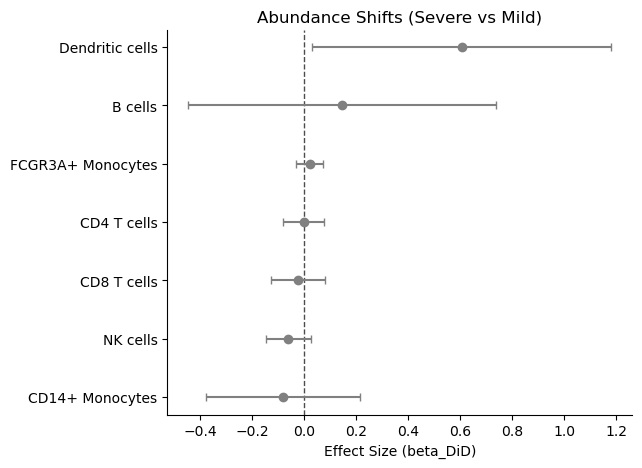

In [9]:
ab_res = st.abundance_did(adata, design, visits=("1-7 days", "8-14 days"))
display(ab_res)

fig, ax = plt.subplots(figsize=(6, 5))
st.plot_did_forest(ab_res, feature_col="celltype", title="Abundance Shifts (Severe vs Mild)", ax=ax)
plt.show()


### Trial UMAP Panel
Visualizing the spatial distribution of the longitudinal IFN response.


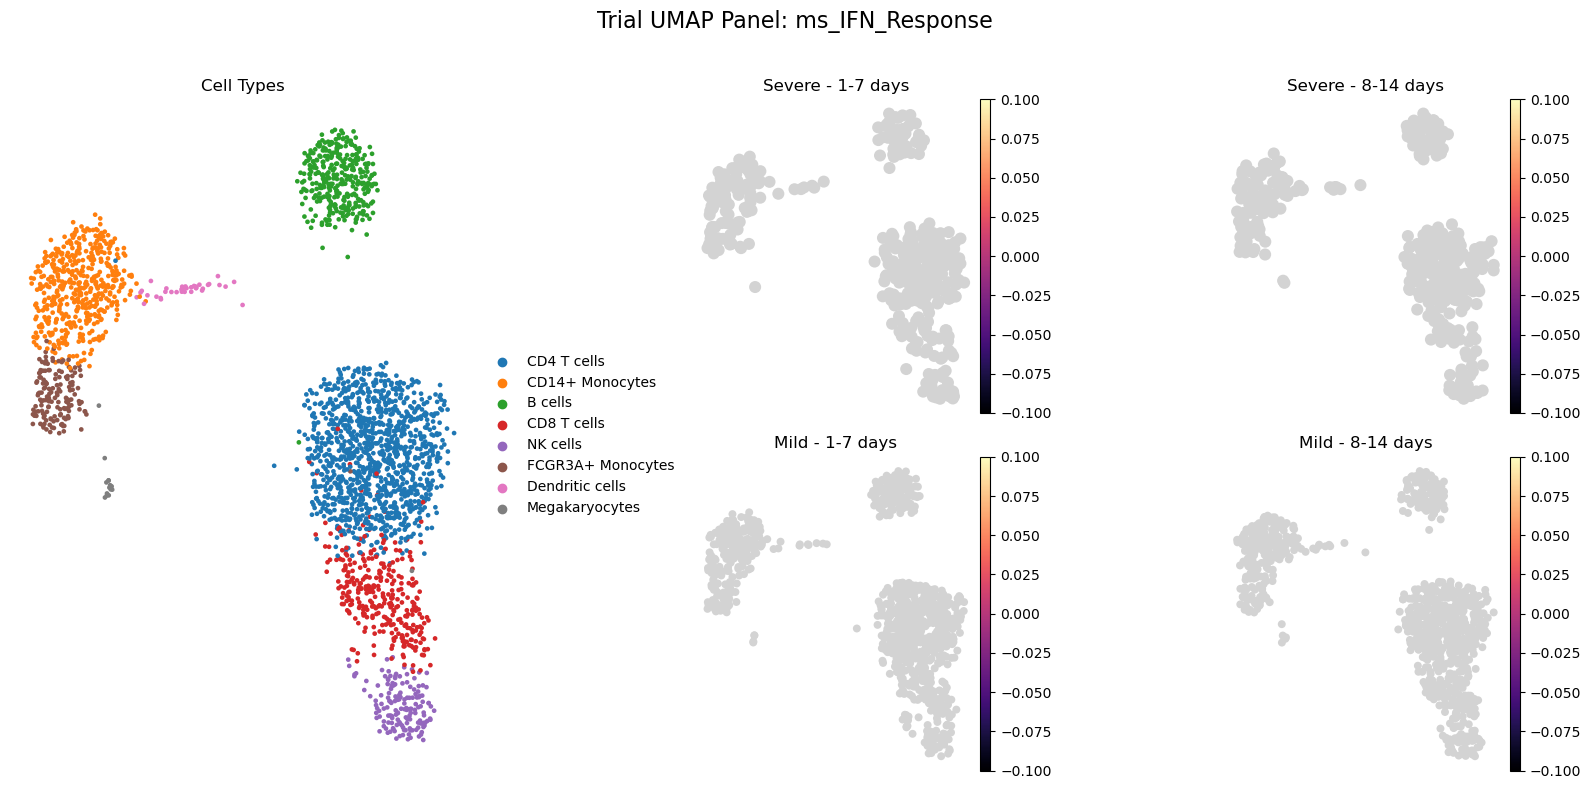

In [10]:
# We'll use the real UMAP coordinates from the pbmc3k_processed dataset
# which show clear clusters
st.plot_trial_umap_panel(adata, "ms_IFN_Response", design, visits=("1-7 days", "8-14 days"))
plt.show()
